In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# reshape
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

### Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### SVM

In [ ]:
svm = SVC(kernel='rbf')
svm.fit(X_train[:10000], y_train[:10000])  # ⚠️加速用 subset

y_pred_svm = svm.predict(X_test)

### Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Using PCA

In [ ]:
pca = PCA(n_components=100)   # 你可以试 50 / 100 / 200
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [9]:
### Logistic Regression
lr_pca = LogisticRegression(max_iter=1000)
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)

In [11]:
### SVM
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_train_pca[:10000], y_train[:10000])
y_pred_svm_pca = svm_pca.predict(X_test_pca)

In [12]:
### Random Forest
rf_pca = RandomForestClassifier(n_estimators=100)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)


## Evaluation

In [10]:
## Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(y_true, y_pred, name):
    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

In [13]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_lr_pca, "LR + PCA")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_svm_pca, "SVM + PCA")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_rf_pca, "RF + PCA")

===== Logistic Regression =====
Accuracy: 0.8437
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.97      0.96      0.96      1000
           2       0.73      0.74      0.73      1000
           3       0.83      0.86      0.84      1000
           4       0.74      0.76      0.75      1000
           5       0.94      0.92      0.93      1000
           6       0.62      0.57      0.59      1000
           7       0.91      0.94      0.93      1000
           8       0.93      0.94      0.93      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

===== LR + PCA =====
Accuracy: 0.841
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1000
           1       0.97      0.96      0.96   

In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results = []

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')  # macro更适合报告
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 (Macro)": f1
    })
add_result("LR", y_test, y_pred_lr)
add_result("SVM", y_test, y_pred_svm)
add_result("RF", y_test, y_pred_rf)

add_result("LR + PCA", y_test, y_pred_lr_pca)
add_result("SVM + PCA", y_test, y_pred_svm_pca)
add_result("RF + PCA", y_test, y_pred_rf_pca)
df_results = pd.DataFrame(results)
df_results.sort_values(by="Accuracy", ascending=False, inplace=True)
df_results.to_csv("model_comparison.csv", index=False)

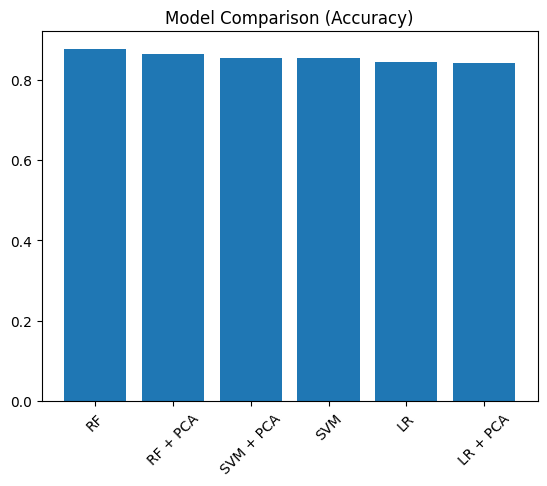

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_results["Model"], df_results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Comparison (Accuracy)")
plt.show()

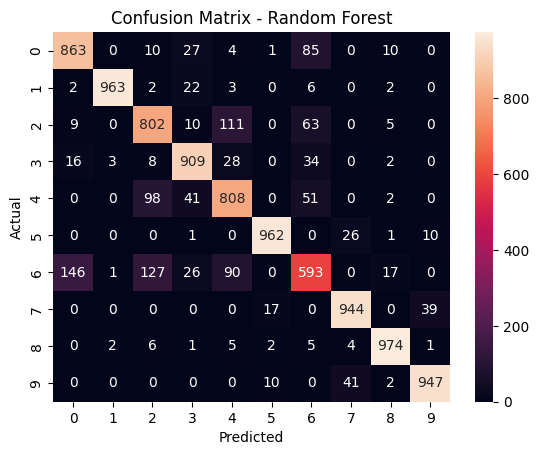

<Axes: >

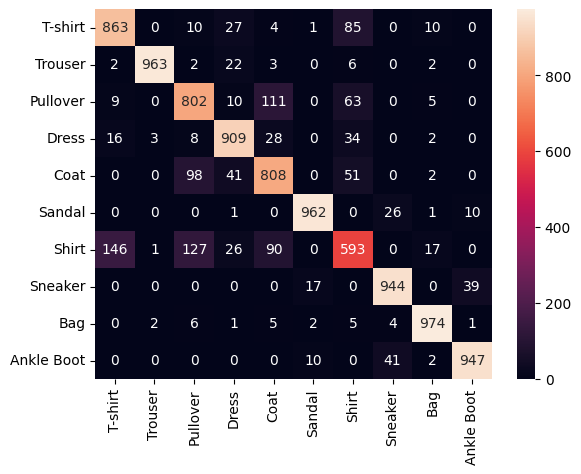

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)


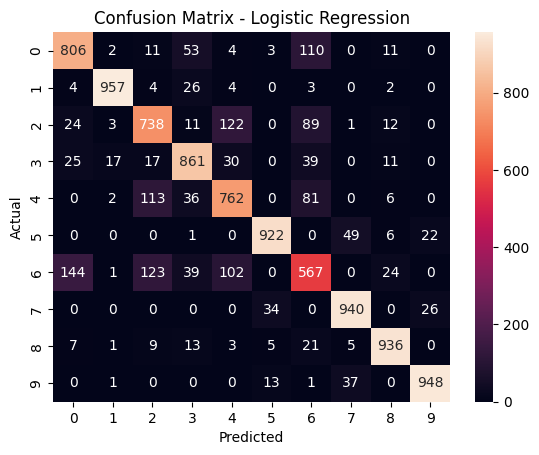

<Axes: >

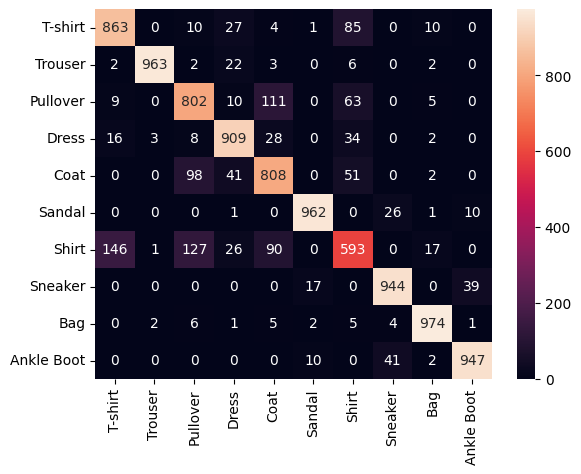

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



<Axes: >

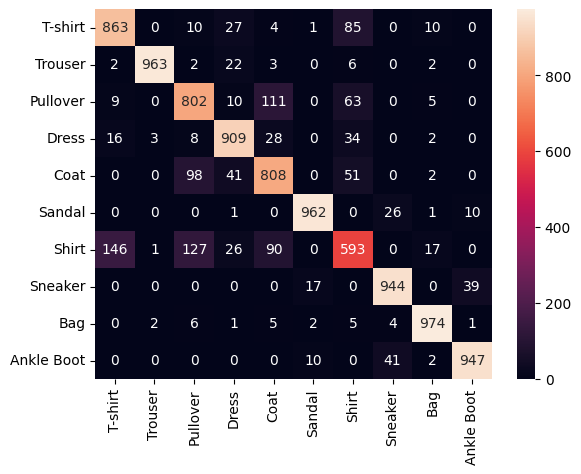

In [20]:
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)